### Проблема подглядывания и последовательное тестирование

История статистики и теории принятия решений показывает, что классические методы гипотезного тестирования, такие как критерий Ньюмана-Пирсона или доверительные интервалы, были разработаны в эпоху, когда сбор данных происходил за фиксированный, заранее определенный объем. В таких условиях, если мы установили уровень значимости и мощность, то можем, основываясь на этих параметрах, провести однократное тестирование гипотезы и сделать окончательное решение. Однако в современной практике, особенно в областях, где данные собираются непрерывно или по мере необходимости — например, в клинических исследованиях, онлайн-экспериментах, промышленной диагностике — появляется новая проблема.

Эта проблема — так называемая **"peeking problem"** или проблема подглядывания. Она заключается в том, что при многократных взглядах на данные, постоянно проверяя гипотезу, увеличивается вероятность ошибочного отрицательного или положительного результата. Проще говоря, если мы смотрим на данные не один раз, а многократно, то вероятность ошибочного отклонения нулевой гипотезы (или её принятия) увеличивается, что подрывает корректность статистических выводов, заложенных в классические тесты.

Эта проблема особенно актуальна в современном мире, где автоматические системы могут в любой момент "подглядеть" за текущими результатами и принять решение. Например, в A/B тестированиях компании могут постоянно мониторить результаты, чтобы мгновенно реагировать на изменения. Однако, если при этом не предпринимать специальных мер, то уровень ложных срабатываний может стать слишком высоким, что подорвет доверие к результатам.

Это привело к необходимости пересмотреть подходы к статистическому тестированию, чтобы оно оставалось корректным даже при многократных взглядах на данные.Чтобы сохранить статистическую корректность при многократных проверках, было предложено несколько концептуальных подходов, которые можно условно разбить на 2 категории:

1. **Коррекция уровня значимости (Alpha-Spending Philosophy)**

Подход, доминирующий в клинических испытаниях, признаёт, что проверки будут в предзаданные моменты, но требуют "платы" в виде доли $\alpha$ за каждую попытку. Эти подходы использую **$\alpha$-spending функции** для распределения $\alpha$ на каждое подглядываение, гарантирование сохранения ошибки 1 рода в рамках номинаного значения.

2. **Всегда валидный вывод (Anytime-Valid Philosophy)**

Самый радикальный подход, формализованный в работах Дарлинга-Роббинса (1967) и современных исследованиях (Ramdas et al., 2020). Его кредо: вывод должен оставаться валидным даже при адаптивном выборе момента остановки. Подходы используют супермартингалы или концентрационные неравенства (например, неравенство Виддерта) для построения таких последовательностей. Пример: в онлайн-эксперименте компания может непрерывно мониторить разницу конверсий, и любой наблюдаемый эффект "сразу" статистически корректен.



Таким образом, возникновение подходов последовательного тестирования — это естественная реакция статистики и теории принятия решений на проблему подглядывания и постоянного мониторинга. Эта область продолжает активно развиваться, предлагая все более универсальные и мощные инструменты для статистического анализа в условиях современного "бесконечного" мониторинга данных, что делает ее важной не только с теоретической точки зрения, но и в прикладных задачах — от медицины и инженерии до онлайн-аналитики и социальных наук.


#### Импорт библиотек

In [2]:
import math
import warnings
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sp
from scipy import stats
from scipy.stats import beta as beta_dist
from scipy.stats import binom, norm
from tqdm import tqdm

warnings.filterwarnings("ignore")

### Sequential Probability Ratio Test

**Историческое введение**

В предвоенные годы, за десятилетие, предшествовавшее Второй мировой войне, наблюдался значительный рост промышленного производства военной продукции, особенно боеприпасов. Одной из ключевых задач стало обеспечение надежности этих изделий. Тестирование боеприпасов — дорогое и зачастую разрушительное, например, при стрельбе из пистолетов или винтовок, — требовало поиска оптимальных методов контроля качества. Встал вопрос: сколько боеприпасов необходимо испытать из партии, чтобы с высокой вероятностью оценить её надежность? Полностью израсходовать весь запас для тестирования было слишком дорого и неэффективно, ведь тогда оставались без боеприпасов.

В 1939 году группа ведущих статистиков и экономистов, объединенная в Статистическую исследовательскую группу (SGR) при Колумбийском университете, занялась решением этой проблемы. В состав группы входили такие выдающиеся ученые, как Уильям Аллен Уоллис, Якоб Вольфовиц и Абрахам Вальд. По словам Уоллиса, группа отличалась исключительным профессионализмом и талантами, что делало её, пожалуй, самой выдающейся в истории статистической науки.

Работа группы имела важное прикладное значение и была засекречена, что отражает уровень важности задач. В частности, Уоллис вспоминал, что Вальд, занимаясь разработкой последовательных тестов, сталкивался с тем, что его бумаги уводили и засекречивали, при этом сам Вальд не имел допуска к секретной информации, поскольку был "врагом по статусу". Группа работала под давлением армии США, которая требовала быстрых и практических решений для боевых условий. Например, во время битвы на Айнзе в декабре 1944 года, офицеры обсуждали параметры взрывателей с помощью результатов исследований Милтона Фридмана, чтобы быстро настроить артиллерийские снаряды для максимальной эффективности.

Ключевым результатом деятельности группы стал так называемый последовательный критерий вероятностной оценки гипотез — метод, получивший название "Последовательный критерий вероятности" (Sequential Probability Ratio Test, SPRT). Идея заключалась в том, чтобы, вместо того чтобы устанавливать фиксированный объем выборки, осуществлять тест последовательно, принимая решение о надежности партии при каждом новом испытании, что позволяло значительно сократить число испытаний и при этом сохранять высокую вероятность правильной оценки.

Идея возникла у Уоллиса и Фридмана: использовать тест, который, хотя и может быть менее эффективен при полном объеме выборки, способен быстрее обнаруживать отклонения и, следовательно, сокращать расходы времени и ресурсов. Вначале Вольфовиц и Вальд отнеслись к этой идее с некоторым скептицизм, поскольку она казалась революционной и даже "сверхмощной" — ведь она превосходила классические тесты по мощности.

Тем не менее, после обсуждений с Фридманом и Уоллисом, Вальд и Вольфовиц начали развивать эту концепцию, которая в конечном итоге стала краеугольным камнем современной теории последовательных тестов гипотез. Эти результаты оставались засекреченными до окончания войны, после чего Вальд опубликовал свою работу ["Последовательные тесты статистических гипотез"](https://www.jstor.org/stable/2235829), которая стала классикой в области статистики.

Этот вклад не только значительно продвинул теорию статистического анализа, но и нашел широкое применение в различных областях — от контроля качества и медицины до военных технологий. Разработанная в условиях секретности, идея последовательных тестов стала мощным инструментом, позволяющим принимать обоснованные решения быстро и экономично в условиях высокой неопределенности.

У нас есть 2 гипотезы о значении какой-то метрики:
$$
H_0 : \theta = \theta_0 \\
H_1 : \theta = \theta_1
$$

Функция **правдоподобия $\mathcal{L}(\theta_i, X_1,X_2, \cdots, X_n)$** показывает, насколько вероятно, что данные $X_1,X_2, \cdots, X_n$ были сгенерированы моделью с параметром $\theta_i$. Отношение правдоподобий же показывает, насколь вероятнее, что одна модель лучше описывает генерацию данных, чем другая. Мы же будем рассматривать логарифм правдоподобия, т.к. это упрощает расчёты:

$$
\Lambda_n = \lambda(X_1,X_2, \cdots, X_n) = \prod^n\frac{\mathcal{L}(\theta_1, X_1,X_2, \cdots, X_n)}{\mathcal{L}(\theta_0, X_1,X_2, \cdots, X_n)}
$$

**Sequential Probability Ratio Test** задаёт правила принятие решения в зависимости от того, где будет$\Lambda_n$ относительно $A$ и $B$ - нижней и верхней границы значения правдоподобия:

$\Lambda_n \ge B \Rightarrow H_0 \text{ выигрывает}$

$\Lambda_n \le A \Rightarrow H_1 \text{ выигрывает}$

$\Lambda_n \in (A \text{ ; } B) \Rightarrow\text{ смотрим } \Lambda_{n+1}$

Значения $A$ и $B$ можно аппроксимировать как $A \approx \log(\frac{\beta}{1-\alpha})$ и $B \approx \log(\frac{1-\beta}{\alpha})$, а вот значения правдоподобия $\Lambda$ надо выводить под каждое из распределений. Ниже мы рассмотрим вывод для Бернулиевской величины:

**Пример**

Пусть $X \sim Bernoulli(\theta,n), P(X_i = 1, \theta) = 1 - P(X_i = 0, \theta) = \theta.$

Тогда $\Lambda_n = \lambda(X_1, X_2, \cdots, X_n) = \log \frac{\theta_1^{\sum X_i}(1-\theta_1)^{n - \sum X_i}}{\theta_0^{\sum X_i} (1-\theta_0)^{n - \sum X_i}}=\log[\theta_1^{\sum X_i}(1-\theta_1)^{n - \sum X_i}] - log[\theta_0^{\sum X_i} (1-\theta_0)^{n - \sum X_i}] = \sum X_i \log \theta_1 + (n - \sum X_i) \log (1-\theta_1) - \sum X_i \log \theta_0 - (n - \sum X_i) \log (1-\theta_0) = \sum X_i \log \frac{\theta_1}{\theta_0} + (n - \sum X_i) \log \frac{1- \theta_1}{1-\theta_0} = \sum X_i \log \frac{\theta_1(1-\theta_0)}{\theta_0(1-\theta_1)} + n \log \frac{1- \theta_1}{1-\theta_0}$

Мы будем продолжать эксперимент, если

$$
\begin{cases}
\Lambda_n < B \\
\Lambda_n > A
\end{cases}
\Rightarrow
\begin{cases}
\sum X_i \log \frac{\theta_1(1-\theta_0)}{\theta_0(1-\theta_1)} + n \log \frac{1- \theta_1}{1-\theta_0} < B \\
\sum X_i \log \frac{\theta_1(1-\theta_0)}{\theta_0(1-\theta_1)} + n \log \frac{1- \theta_1}{1-\theta_0} > A
\end{cases}
\Rightarrow
\begin{cases}
\sum X_i > \rho A + \eta \rho n \\
\sum X_i < \rho B + \eta \rho n
\end{cases}
\quad \text{где}
\begin{cases}
\rho^{-1} = \log\frac{\theta_1(1-\theta_0)}{\theta_0 (1-\theta_1)} \\
\eta = \log\frac{1-\theta_0}{1-\theta_1}
\end{cases}
$$

То есть границы - параллельные прямые с $k = \rho \eta$ и $b = (\rho A, \rho B)$

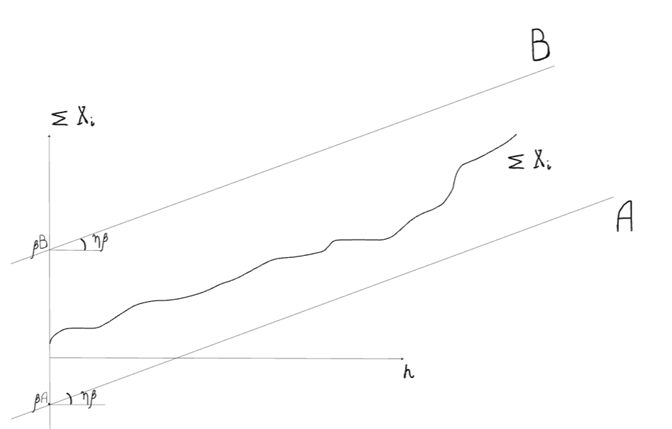


Как видно, у этого подхода есть 3 главных проблемы, которые затрудняют его использование в A/B тестах:

1. **Ограничение одной выборки.** Простой SPRT предполагает, что данные поступают из одной выборки, что делает его прямое использование неприменимым для задач, где необходимо сравнивать две или более выборки.
2. **Простота дизайна альтернативной гипотезы.** Простой SPRT требует, чтобы альтернативная гипотеза была задана в виде фиксированного значения параметра $\theta_1$. Это ограничивает его гибкость, так как в реальных задачах альтернативная гипотеза часто имеет более сложный характер.
3. **Неограниченность теста.** Как видно из визуализации, границы $A$ и $B$ представляют из себя параллельные прямые, из-за чего эксперимент не имеет естественной границы остановки. (хотя с 100% вероятность статистика пересечет одну из границ, но это может быть несуразно долго)


Все последующие улучшения и дизайны последовательного тестирования призваны решить эти проблемы

#### Функции

In [5]:
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt
from typing import Dict, Tuple

# ================== Генерация данных ==================
def generate_ab_data(
    conversion_A: float,
    conversion_B: float,
    sample_size: int,
    random_seed: int = None
) -> Tuple[np.ndarray, np.ndarray]:
    """Генерирует данные для A/B теста."""
    if random_seed is not None:
        np.random.seed(random_seed)
    return (
        np.random.binomial(1, conversion_A, sample_size),
        np.random.binomial(1, conversion_B, sample_size)
    )

# ================== SPRT функции ==================
def binomial_log_likelihood_ratio(
    successes_A: int, failures_A: int,
    successes_B: int, failures_B: int,
    p0: float, effect_size: float  # Переименовали delta в effect_size
) -> float:
    """Вычисляет логарифмическое отношение правдоподобия для биномиального SPRT."""
    n_A = successes_A + failures_A
    n_B = successes_B + failures_B
    return (binom.logpmf(successes_B, n_B, p0 + effect_size) -
            binom.logpmf(successes_B, n_B, p0))

def run_SPRT(
    data_A: np.ndarray, data_B: np.ndarray,
    p0: float, effect_size: float,  # Переименовали delta в effect_size
    alpha: float = 0.05, beta_error: float = 0.2,  # Переименовали beta в beta_error
    max_samples: int = None
) -> Dict:
    """Выполняет последовательный SPRT тест."""
    successes_A = failures_A = successes_B = failures_B = 0
    lower_bound = np.log(beta_error / (1 - alpha))
    upper_bound = np.log((1 - beta_error) / alpha)
    log_lr_sequence = []

    max_samples = min(max_samples or len(data_A), len(data_A), len(data_B))

    for i in range(max_samples):
        successes_A += data_A[i] == 1
        failures_A += data_A[i] == 0
        successes_B += data_B[i] == 1
        failures_B += data_B[i] == 0

        current_log_lr = binomial_log_likelihood_ratio(
            successes_A, failures_A, successes_B, failures_B, p0, effect_size)
        log_lr_sequence.append(current_log_lr)

        if current_log_lr <= lower_bound:
            return {'method': 'SPRT', 'decision': 'A', 'log_lr': log_lr_sequence,
                    'stopping_step': i+1, 'bounds': (lower_bound, upper_bound),
                    'conversion_A': successes_A/(successes_A+failures_A),
                    'conversion_B': successes_B/(successes_B+failures_B)}
        elif current_log_lr >= upper_bound:
            return {'method': 'SPRT', 'decision': 'B', 'log_lr': log_lr_sequence,
                    'stopping_step': i+1, 'bounds': (lower_bound, upper_bound),
                    'conversion_A': successes_A/(successes_A+failures_A),
                    'conversion_B': successes_B/(successes_B+failures_B)}

    return {'method': 'SPRT', 'decision': 'continue', 'log_lr': log_lr_sequence,
            'stopping_step': max_samples, 'bounds': (lower_bound, upper_bound),
            'conversion_A': successes_A/(successes_A+failures_A),
            'conversion_B': successes_B/(successes_B+failures_B)}

def plot_test_results(results: Dict, ax=None):
    """Визуализация результатов теста."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(17, 6))

    ax.plot(results['log_lr'], label='Статистика', color='blue')
    lower, upper = results['bounds']

    ax.axhline(upper, color='r', linestyle='--',
               label='Верхняя граница (Отклонить $H_0$)')
    ax.axhline(lower, color='g', linestyle='--',
               label='Нижняя граница (Отклонить $H_1$)')

    ax.set_xlabel('Размер выборки')
    ax.set_ylabel('Логарифм отношения правдоподобия')
    ax.set_title(f"{results['method']} - Решение: {results['decision']}")
    ax.legend()
    ax.grid(True)

    info_text = (f"Конверсия A: {results['conversion_A']:.3f}\n"
                 f"Конверсия B: {results['conversion_B']:.3f}\n"
                 f"Шагов: {results['stopping_step']}")
    ax.text(0.7, 0.15, info_text, transform=ax.transAxes,
            bbox=dict(facecolor='white', alpha=0.8))

#### Реализация

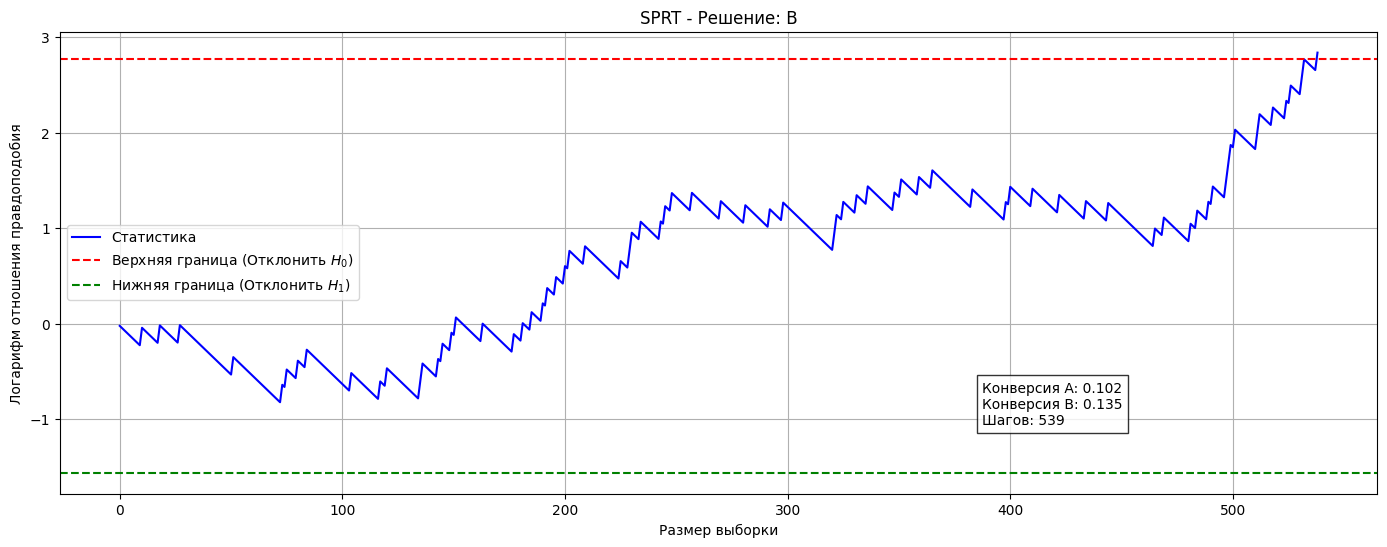

In [6]:
# Параметры эксперимента
CONVERSION_A = 0.10
CONVERSION_B = 0.12  # Эффект 2%
SAMPLE_SIZE = 10_000
RANDOM_SEED = 666

# Генерация данных (одинаковых для обоих тестов)
data_A, data_B = generate_ab_data(
    conversion_A=CONVERSION_A,
    conversion_B=CONVERSION_B,
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED
)

# Параметры тестов
p0 = CONVERSION_A
effect_size = 0.02  # Минимальный детектируемый эффект (2%)
alpha = 0.05  # Уровень значимости
beta_error = 0.2    # Вероятность ошибки II рода

sprt_res = run_SPRT(
                    data_A = data_A, data_B = data_B,
                    p0 = p0, effect_size = effect_size,
                    alpha = 0.05, beta_error = 0.2,
                    max_samples = None
                   )

plot_test_results(sprt_res)

### mixture Sequential Probability Ratio Test

mSPRT это естественное продолжение базового SPRT, призванное решить проблему ограничения одной выборки, а именно — проблему фиксированной альтернативы. В классическом SPRT мы проверяем простую гипотезу против простой альтернативы ($H_0$: $\theta$ = $\theta_0$ против $H_1$: $\theta$ = $\theta_1$). Но на практике мы часто не знаем точное значение эффекта ($\theta_1$). В mSPRT вместо того, чтобы смотреть на конкретное значение оцениваемого параметра, как в случае с простой гипотезой, предлагается оценивать (как в байесовском подходе) распределение параметра при верности альтернативной гипотезы.

Основная его идея заключается в следующем: поскольку это двусторонний тест, обозначим $H_0$: $\theta$ = $\theta_0$ и $H_1$: $\theta$ ≠ $\theta_0$ как нулевую и альтернативную гипотезы соответственно. То есть мы допускаем, что эффект может быть как в положительную, так и в отрицательную сторону, и любого размера.

Мы определяем H как смешивающее распределение по $\Theta$ с плотностью $h$. Проще говоря, мы «взвешиваем» все возможные значения параметра $\theta$ согласно некоторому распределению (например, нормальному), чтобы охватить весь спектр возможных эффектов под альтернативой.

Пусть $f_0$ будет плотностью данных с параметром $\theta$ (правдоподобие). Тогда смешивание $H$ по пространству параметров $\theta$ означает применение вероятностного распределения к возможным значениям тестируемого параметра. Вместо того чтобы спрашивать: «Насколько вероятны данные при конкретном $\theta_1$ по сравнению с $\theta_0$?», мы спрашиваем: «Какова средняя вероятность данных по всему пространству альтернатив, взвешенная нашим априорным распределением $h(\theta)$?»

mSPRT - естественное продолжение базового SPRT, призванное решить проблему ограничения одной выборки. Здесь вместо того, чтобы смотреть на конкретное значение оцениваемого параметра, предлагается оценивать (как в байесовском подходе) распределение параметра при верности альтернативной гипотезы.

Формально это выражается формулой отношения правдоподобия для смеси:
$$
\Lambda_n = \int_{\Theta} \prod^{n} \frac{L(\theta_1, X_n)}{L(\theta_0, X_n)}h(\theta)d\theta
$$


Здесь $h(\theta)$ — это функция плотности смеси (везде положительная), которая контролирует распределение альтернативной гипотезы, проверяемой в отношении правдоподобия. Таким образом, mSPRT позволяет учитывать неопределённость в параметрах и делать тест более универсальным. Но пока это по прежнему одновыборочный тест.


Правило принятия решения в mSPRT аналогично правилу в простом SPRT.

#### Функции

In [21]:
import numpy as np
from scipy.stats import norm
from scipy.special import betaln, logsumexp
import matplotlib.pyplot as plt
from typing import Dict, Tuple, Optional

# ----------------------------------------------------------------------
# Генерация данных
# ----------------------------------------------------------------------
def generate_ab_data(
    conversion_A: float,
    conversion_B: float,
    sample_size: int,
    random_seed: int = None
) -> Tuple[np.ndarray, np.ndarray]:
    """Генерирует данные для A/B теста (бернуллиевские величины)."""
    if random_seed is not None:
        np.random.seed(random_seed)
    return (
        np.random.binomial(1, conversion_A, sample_size),
        np.random.binomial(1, conversion_B, sample_size)
    )

# ----------------------------------------------------------------------
# Класс mSPRT с корректным интегрированием
# ----------------------------------------------------------------------
class MSPRT:
    """
    mSPRT для сравнения двух бернуллиевских выборок.

    Модель:
      H0: θ_A = θ_B = θ
      H1: θ_B = θ_A + δ, δ ≠ 0

    Смешивающее распределение для δ: нормальное N(0, σ_δ²), усечённое до [-0.5, 0.5].
    Априорное распределение для базовой конверсии θ: Beta(α, β).

    Интегрирование выполняется по сетке δ (с весом h(δ) dδ) и по θ (с весом prior(θ) dθ).
    """

    def __init__(self,
                 prior_alpha: float = 1.0,
                 prior_beta: float = 1.0,
                 prior_delta_std: float = 0.1,
                 n_delta: int = 40,
                 n_theta: int = 50):
        """
        Параметры:
          prior_alpha, prior_beta : параметры бета-априорного для θ.
          prior_delta_std : стандартное отклонение нормального смешивающего распределения для δ.
          n_delta, n_theta : число точек дискретизации для интегрирования.
        """
        self.prior_alpha = prior_alpha
        self.prior_beta = prior_beta
        self.prior_delta_std = prior_delta_std

        # Дискретизация δ в разумных пределах (от -0.5 до 0.5, но с учётом 3σ)
        delta_limit = min(0.5, 3 * prior_delta_std)
        self.delta_grid = np.linspace(-delta_limit, delta_limit, n_delta)
        self.d_delta = (self.delta_grid[-1] - self.delta_grid[0]) / (n_delta - 1)
        self.log_d_delta = np.log(self.d_delta)

        # Значения плотности нормального распределения (не нормализованные)
        self.delta_pdf = norm.pdf(self.delta_grid, 0, prior_delta_std)
        self.log_delta_pdf = np.log(self.delta_pdf + 1e-300)  # избегаем -inf

        # Дискретизация θ (базовая конверсия) от 0.01 до 0.99
        self.theta_grid = np.linspace(0.01, 0.99, n_theta)
        self.dtheta = self.theta_grid[1] - self.theta_grid[0]
        self.log_dtheta = np.log(self.dtheta)

        # Предвычисление логарифма априорной плотности для θ (Beta)
        log_prior_theta = ((prior_alpha - 1) * np.log(self.theta_grid) +
                           (prior_beta - 1) * np.log(1 - self.theta_grid) -
                           betaln(prior_alpha, prior_beta))
        self.log_prior_theta = log_prior_theta  # вектор размера n_theta

    def _log_likelihood_null(self, sA, fA, sB, fB):
        """Логарифм маргинального правдоподобия при H0 (интеграл по θ)."""
        # Аналитический интеграл: B(sA+sB+α, fA+fB+β) / B(α,β)
        return betaln(sA + sB + self.prior_alpha,
                      fA + fB + self.prior_beta) - betaln(self.prior_alpha, self.prior_beta)

    def _log_likelihood_alt_delta(self, delta, sA, fA, sB, fB):
        """
        Логарифм маргинального правдоподобия при фиксированном δ.
        Возвращает скаляр.
        """
        # Проверка допустимости δ
        if delta <= -1 or delta >= 1:
            return -np.inf

        # Для текущего δ вычисляем правдоподобие на сетке θ
        theta_B = self.theta_grid + delta
        # Маска допустимых значений: θ в (0,1) и θ+δ в (0,1)
        valid = (self.theta_grid > 0) & (self.theta_grid < 1) & (theta_B > 0) & (theta_B < 1)
        if not np.any(valid):
            return -np.inf

        # Логарифм правдоподобия для каждой допустимой θ
        log_like = (sA * np.log(self.theta_grid[valid]) +
                    fA * np.log(1 - self.theta_grid[valid]) +
                    sB * np.log(theta_B[valid]) +
                    fB * np.log(1 - theta_B[valid]))

        # Полный логарифм подынтегрального выражения: правдоподобие * априорная плотность * dθ
        log_integrand = log_like + self.log_prior_theta[valid] + self.log_dtheta

        # Возвращаем log(∫ ... dθ) через logsumexp
        return logsumexp(log_integrand)

    def compute_log_lr(self,
                       successes_A: int, failures_A: int,
                       successes_B: int, failures_B: int) -> float:
        """
        Вычисляет логарифм отношения правдоподобия для mSPRT:
            Λ = ∫ LR(δ) h(δ) dδ,
        где LR(δ) = L_alt(δ) / L_null.
        Возвращает log Λ.
        """
        # Знаменатель (H0)
        log_null = self._log_likelihood_null(successes_A, failures_A,
                                              successes_B, failures_B)
        if log_null == -np.inf:
            return np.inf  # данные невозможны при H0

        # Массив для хранения log(LR(δ) * h(δ) * dδ) для каждого δ
        log_values = []
        for i, delta in enumerate(self.delta_grid):
            log_alt = self._log_likelihood_alt_delta(delta,
                                                      successes_A, failures_A,
                                                      successes_B, failures_B)
            if log_alt > -np.inf:
                # log(LR(δ) * h(δ) dδ) = (log_alt - log_null) + log(h(δ)) + log(dδ)
                log_values.append(log_alt - log_null + self.log_delta_pdf[i] + self.log_d_delta)

        if not log_values:
            return -np.inf  # ни один δ не дал конечного правдоподобия

        # Интегрирование по δ: log(∫ exp(...) dδ) = logsumexp(log_values)
        return logsumexp(log_values)

# ----------------------------------------------------------------------
# Функция запуска mSPRT
# ----------------------------------------------------------------------
def run_mSPRT(
    data_A: np.ndarray,
    data_B: np.ndarray,
    alpha: float = 0.05,
    beta_error: float = 0.2,
    prior_alpha: float = 1.0,
    prior_beta: float = 1.0,
    prior_delta_std: float = 0.1,
    max_samples: Optional[int] = None,
    verbose: bool = False
) -> Dict:
    """
    Запускает последовательный mSPRT на потоке данных.

    Возвращает словарь с результатами.
    """
    max_samples = min(max_samples or len(data_A), len(data_A), len(data_B))

    # Кумулятивные суммы для эффективного обновления
    cumsum_A = np.cumsum(data_A[:max_samples])
    cumsum_B = np.cumsum(data_B[:max_samples])
    n_A = np.arange(1, max_samples + 1)
    n_B = np.arange(1, max_samples + 1)

    successes_A = cumsum_A
    failures_A = n_A - cumsum_A
    successes_B = cumsum_B
    failures_B = n_B - cumsum_B

    # Границы SPRT
    upper_bound = np.log((1 - beta_error) / alpha)
    lower_bound = np.log(beta_error / (1 - alpha))

    # Инициализация калькулятора
    calculator = MSPRT(prior_alpha=prior_alpha,
                       prior_beta=prior_beta,
                       prior_delta_std=prior_delta_std)

    log_lr_sequence = []
    decision = 'continue'

    for i in range(max_samples):
        current_log_lr = calculator.compute_log_lr(
            successes_A[i], failures_A[i],
            successes_B[i], failures_B[i]
        )
        log_lr_sequence.append(current_log_lr)

        if current_log_lr <= lower_bound:
            decision = 'Принять H₀ (конверсии равны)'
            break
        elif current_log_lr >= upper_bound:
            decision = 'Отклонить H₀ (конверсии различаются)'
            break
    else:
        i = max_samples - 1

    return {
        'method': f'mSPRT (σ_δ={prior_delta_std})',
        'decision': decision,
        'log_lr': log_lr_sequence,
        'stopping_step': i + 1,
        'bounds': (lower_bound, upper_bound),
        'conversion_A': successes_A[i] / n_A[i] if i >= 0 else 0,
        'conversion_B': successes_B[i] / n_B[i] if i >= 0 else 0,
        'final_statistic': log_lr_sequence[-1] if log_lr_sequence else 0
    }

# ----------------------------------------------------------------------
# Визуализация
# ----------------------------------------------------------------------
def plot_test_results(results: Dict, ax=None):
    """Рисует динамику логарифма отношения правдоподобия и границы."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(results['log_lr'], label='mSPRT статистика', color='blue', linewidth=2)
    lower, upper = results['bounds']

    ax.axhline(upper, color='red', linestyle='--', linewidth=2,
               label=f'Верхняя граница (отклонить H₀) = {upper:.2f}')
    ax.axhline(lower, color='green', linestyle='--', linewidth=2,
               label=f'Нижняя граница (принять H₀) = {lower:.2f}')
    ax.axhline(0, color='gray', linestyle='-', alpha=0.3)

    stop_step = results['stopping_step']
    if stop_step < len(results['log_lr']):
        ax.axvline(stop_step, color='orange', linestyle=':',
                   label=f'Остановка на {stop_step}')

    ax.set_xlabel('Размер выборки')
    ax.set_ylabel('Логарифм отношения правдоподобия')
    ax.set_title(f"{results['method']} – Решение: {results['decision']}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    info_text = (f"Конверсия A: {results['conversion_A']:.4f}\n"
                 f"Конверсия B: {results['conversion_B']:.4f}\n"
                 f"Разница: {results['conversion_B'] - results['conversion_A']:.4f}\n"
                 f"Шагов: {results['stopping_step']}")
    ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
            bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'),
            verticalalignment='top')

#### Реализация

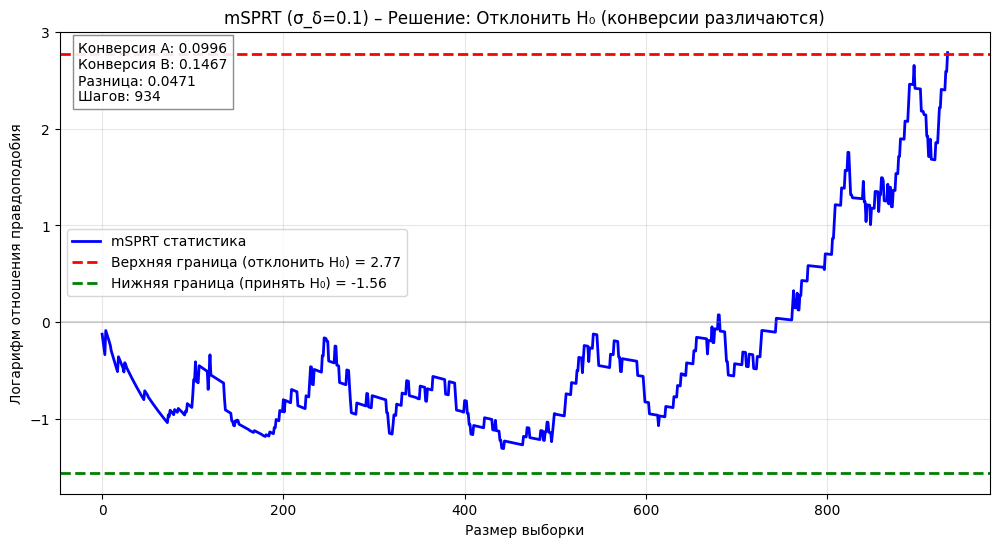

In [20]:
# Параметры эксперимента
CONVERSION_A = 0.10
CONVERSION_B = 0.12   # истинная разница 2%
SAMPLE_SIZE = 10_000
RANDOM_SEED = 666

# Генерация данных
data_A, data_B = generate_ab_data(
    conversion_A=CONVERSION_A,
    conversion_B=CONVERSION_B,
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED
)

# Параметры теста
alpha = 0.05
beta_error = 0.2

# Запуск mSPRT
msprt_res = run_mSPRT(
    data_A=data_A,
    data_B=data_B,
    alpha=alpha,
    beta_error=beta_error,
    prior_alpha=1.0,
    prior_beta=1.0,
    prior_delta_std=0.1,
    max_samples=None
)

# Визуализация
plot_test_results(msprt_res)
plt.show()

### Always Valid Inference

Always-Valid Inference (всегда валидный статистический вывод) — это подход в статистике, где p-значения и доверительные интервалы остаются валидными (корректными) на протяжении всего последовательного сбора данных, а не только в фиксированный момент времени.

Формально p-значение называется **always-valid**, если для любого момента времени $t$ и любого уровня значимости $\alpha$:
$$
P(\text{p-value}_{t} \le \alpha \mid H_0) \le \alpha
$$

AVI включают в себя несколько больших класов подходов:

* **Последовательные тесты** - останавливаются, когда накоплено "достаточно доказательств".

* **Always-Valid p-значения** - специальные p-значения, которые можно проверять многократно.

* **Последовательные доверительные интервалы** - интервалы, которые остаются валидными при любом промежуточном размере выборки.


---

**1. Always-Valid p-значения (Always-Valid p-values)**

**Концепция:** Классическое p-значение, рассчитанное для фиксированного размера выборки, теряет свою валидность, если на данные смотрят несколько раз. Always-valid p-значение — это последовательность $p_t$, которая контролирует ошибку I рода для любого случайного момента остановки $T$ .

**Математическая формализация:**
Последовательность случайных величин $(p_t)_{t=1}^\infty$ является always-valid, если для любого уровня значимости $\alpha \in (0,1)$ и любого момента остановки $T$ (относительно фильтрации, порожденной данными) выполняется:
$$
P_{H_0}(p_T \le \alpha) \le \alpha.
$$
Это более сильное условие, чем поточечный контроль: $P_{H_0}(p_t \le \alpha) \le \alpha$ для каждого фиксированного $t$ .

**Построение через e-значения:**
Ключевой современный подход к построению always-valid p-значений основан на **e-значениях (e-values)** . E-значение — это неотрицательная случайная величина $E$, такая что $\mathbb{E}_{H_0}[E] \le 1$.

Если мы построим неотрицательный супермартингал $(M_t)_{t\ge0}$ относительно фильтрации данных с $M_0=1$, то величина $1/M_t$ является always-valid p-значением. Это следует из неравенства Вилле (Ville's inequality):
$$
P_{H_0}\left( \sup_{t \ge 0} M_t \ge \frac{1}{\alpha} \right) \le \alpha.
$$
Тогда, определив $p_t = \min(1, 1/\sup_{s \le t} M_s)$, мы получаем искомое свойство .

**Пример для A/B-теста (mSPRT):**
В методе mSPRT (Mixture Sequential Probability Ratio Test) мы строим процесс на основе смеси отношений правдоподобия :
$$
\Lambda_n^H = \int_{\Theta} \left( \frac{f_{\theta}(data)}{f_{\theta_0}(data)} \right) dH(\theta).
$$
При нулевой гипотезе $\mathbb{E}[\Lambda_n^H] \le 1$, а сам процесс $\Lambda_n^H$ является мартингалом относительно $n$. Тогда always-valid p-значение вычисляется как :
$$
p_0 = 1; \quad p_n = \min\left(p_{n-1}, \frac{1}{\Lambda_n^H}\right).
$$

---

**2. Последовательные доверительные интервалы (Confidence Sequences)**

**Концепция:** Если классический доверительный интервал покрывает истинный параметр с вероятностью $1-\alpha$ только для заранее заданного размера выборки $n$, то доверительная последовательность $(C_t)_{t=1}^\infty$ покрывает параметр **одновременно для всех** моментов времени $t$ с высокой вероятностью .

**Математическая формализация:**
Пусть $\psi$ — целевой параметр. Последовательность интервалов $(C_t)_{t=1}^\infty$ называется доверительной последовательностью (Confidence Sequence, CS) уровня $1-\alpha$, если:
$$
P\left( \forall t \ge 1: \psi \in C_t \right) \ge 1 - \alpha.
$$
Это означает, что вероятность того, что истинный параметр **когда-либо** выйдет за пределы построенного интервала, не превышает $\alpha$ .

**Построение через двойственность с тестами:**
Существует тесная связь между доверительными последовательностями и always-valid тестами. Если для каждого гипотетического значения параметра $\psi_0$ у нас есть always-valid тест, который отвергает $H_0: \psi = \psi_0$ при уровне $\alpha$, то мы можем построить CS, инвертируя эти тесты.

**Пример для разности средних (неравенство Хёффдинга):**
Для ограниченных наблюдений $X_i \in [a,b]$ со средним $\mu$, экспоненциальный супермартингал Хёффдинга позволяет построить time-uniform границы. Для разности конверсий $D_i \in [-1,1]$ (как в вашем тексте) граница имеет вид:
$$
|\bar{D}_t - \Delta| \le u_t(\alpha) = \sqrt{\frac{2\sigma^2 \log(2/\alpha)}{t}} + \frac{2\log(2/\alpha)}{3t},
$$
где $\sigma$ — оценка размаха или дисперсии. Интервал $[\bar{D}_t - u_t, \bar{D}_t + u_t]$ является $(1-\alpha)$-доверительной последовательностью для истинной разности $\Delta$ .

---

**3. Последовательные тесты (Sequential Tests) / E-процессы**

**Концепция:** Класс методов, позволяющих принимать статистические решения (остановиться и отвергнуть $H_0$ или продолжить сбор данных) в любой момент времени, сохраняя при этом строгий контроль над ошибками. Современный подход к этому — использование **e-процессов (e-processes)**.

**Математическая формализация:**
E-процесс — это неотрицательный процесс $(E_t)_{t \ge 0}$, адаптированный к фильтрации данных, такой что для любого момента остановки $T$ выполняется $\mathbb{E}_{H_0}[E_T] \le 1$ . Это обобщение понятия "e-значение" на последовательный сбор данных.

Любой e-процесс можно использовать для последовательной проверки гипотез. Правило остановки формулируется следующим образом:
$$
\text{Остановиться и отвергнуть } H_0 \text{ в первый момент } \tau, \text{ когда } E_\tau \ge 1/\alpha.
$$
В силу неравенства Вилле, вероятность ложного срабатывания (ошибки I рода) при такой стратегии не превышает $\alpha$, независимо от того, когда именно мы остановились .

**Пример: Экспоненциальный супермартингал Хёффдинга**
Для последовательности независимых ограниченных случайных величин $X_i \in [a,b]$ с нулевым средним при $H_0$, процесс
$$
M_t(\lambda) = \exp\left( \lambda \sum_{i=1}^t X_i - \frac{t \lambda^2 (b-a)^2}{8} \right)
$$
является супермартингалом. Для любого $\lambda$, $M_t$ — это e-процесс. Чтобы избежать зависимости от выбора $\lambda$, можно использовать смесь (mixture):
$$
\tilde{M}_t = \int M_t(\lambda) dH(\lambda).
$$
Полученный процесс $\tilde{M}_t$ также является e-процессом и лежит в основе mSPRT .

#### Функции

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Tuple, Optional

# ----------------------------------------------------------------------
# Генерация данных
# ----------------------------------------------------------------------
def generate_ab_data(
    conversion_A: float,
    conversion_B: float,
    sample_size: int,
    random_seed: int = None
) -> Tuple[np.ndarray, np.ndarray]:
    """Генерирует данные для A/B теста (бернуллиевские величины)."""
    if random_seed is not None:
        np.random.seed(random_seed)
    return (
        np.random.binomial(1, conversion_A, sample_size),
        np.random.binomial(1, conversion_B, sample_size)
    )

# ----------------------------------------------------------------------
# Основные вычисления AVI (Always-Valid Inference)
# ----------------------------------------------------------------------
def compute_avi_metrics(
    data_A: np.ndarray,
    data_B: np.ndarray,
    alpha: float = 0.05,
    max_samples: Optional[int] = None
) -> Dict:
    """
    Вычисляет доверительную последовательность и always-valid p-value
    для разности конверсий Δ = p_B - p_A на основе экспоненциального
    супермартингала Хёффдинга.

    Параметры:
        data_A, data_B: массивы бинарных наблюдений (0/1)
        alpha: уровень значимости (1 - доверительная вероятность)
        max_samples: максимальное число наблюдений для анализа

    Возвращает словарь с массивами:
        t: номера шагов (1,2,...,T)
        S: кумулятивная сумма разностей D_i = B_i - A_i
        mean: выборочное среднее разности
        u: полуширина доверительного интервала
        lower: нижняя граница доверительной последовательности
        upper: верхняя граница
        p_raw: "сырое" p-значение (только для текущего t)
        p_av: always-valid p-значение (минимум по всем прошлым p_raw)
    """
    max_samples = min(max_samples or len(data_A), len(data_A), len(data_B))

    # Разность наблюдений
    D = data_B[:max_samples] - data_A[:max_samples]   # значения -1, 0, 1

    # Кумулятивная сумма и среднее
    S = np.cumsum(D)
    t = np.arange(1, max_samples + 1)
    mean = S / t

    # Константа размаха (c = b - a, где D_i ∈ [a,b] = [-1,1])
    c = 2.0

    # ---- ФОРМУЛА ДЛЯ ГРАНИЦЫ u_t ----
    # Используем консервативную оценку дисперсии (c/2)^2 = 1
    # Первое слагаемое: sqrt(2 * (c/2)^2 * log(2/alpha) / t) = sqrt(2 * 1 * log(2/alpha) / t)
    # Второе слагаемое: (2 * c * log(2/alpha)) / (3 * t)   (из теоремы Johari et al.)
    u = np.sqrt(2 * np.log(2.0 / alpha) / t) + (2 * c * np.log(2.0 / alpha)) / (3 * t)

    # Доверительные интервалы
    lower = mean - u
    upper = mean + u

    # ---- ФОРМУЛА ДЛЯ p-ЗНАЧЕНИЯ ----
    # По неравенству Хёффдинга: P(|S_t| ≥ s) ≤ 2 exp(-2 s^2 / (c^2 t))
    # При наблюдаемом S_t, p-value = 2 exp(-2 S_t^2 / (c^2 t))
    p_raw = 2.0 * np.exp(-2.0 * S**2 / (c**2 * t))
    # Ограничиваем сверху единицей (p-value не может быть >1)
    p_raw = np.minimum(p_raw, 1.0)

    # Always-valid p-значение: минимум по всем прошлым значениям
    p_av = np.minimum.accumulate(p_raw)

    return {
        't': t,
        'S': S,
        'mean': mean,
        'u': u,
        'lower': lower,
        'upper': upper,
        'p_raw': p_raw,
        'p_av': p_av,
        'alpha': alpha,
        'c': c
    }

# ----------------------------------------------------------------------
# Запуск последовательного теста на основе AVI
# ----------------------------------------------------------------------
def run_avi_test(
    data_A: np.ndarray,
    data_B: np.ndarray,
    alpha: float = 0.05,
    max_samples: Optional[int] = None,
    stop_on_pvalue: bool = True
) -> Dict:
    """
    Запускает последовательный тест с always-valid p-value.
    Останавливается, как только p_av ≤ alpha (отвергает H₀)
    или достигает максимума выборки.

    Параметры:
        data_A, data_B: массивы наблюдений
        alpha: уровень значимости
        max_samples: максимальное число шагов
        stop_on_pvalue: если True, останавливается при p_av ≤ alpha

    Возвращает словарь с результатами теста и полными вычислениями.
    """
    # Полные вычисления
    full = compute_avi_metrics(data_A, data_B, alpha, max_samples)

    t = full['t']
    p_av = full['p_av']

    if stop_on_pvalue:
        # Ищем первый момент, когда p_av ≤ alpha
        stop_indices = np.where(p_av <= alpha)[0]
        if len(stop_indices) > 0:
            stop_idx = stop_indices[0]  # первое пересечение
            decision = 'Отклонить H₀ (конверсии различаются)'
        else:
            stop_idx = len(t) - 1
            decision = 'Не отклонять H₀ (достигнут максимум выборки)'
    else:
        # Если не останавливаемся по p-value, просто берём последний шаг
        stop_idx = len(t) - 1
        decision = 'Анализ завершён (без ранней остановки)'

    # Формируем результат
    result = {
        'method': 'AVI (Hoeffding CS)',
        'decision': decision,
        'stopping_step': t[stop_idx],
        'alpha': alpha,
        'final_mean': full['mean'][stop_idx],
        'final_ci': (full['lower'][stop_idx], full['upper'][stop_idx]),
        'final_p_av': p_av[stop_idx],
        'full': full  # все данные для визуализации
    }
    return result

# ----------------------------------------------------------------------
# Визуализация
# ----------------------------------------------------------------------
def plot_avi_results(result: Dict, figsize=(14, 10)):
    """
    Рисует два графика:
      1. Always-valid p-value с порогом alpha.
      2. Доверительную последовательность для разности конверсий.
    """
    full = result['full']
    t = full['t']
    p_av = full['p_av']
    alpha = full['alpha']
    mean = full['mean']
    lower = full['lower']
    upper = full['upper']
    stop_step = result['stopping_step']

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize)

    # ----- График p-value -----
    ax1.plot(t, p_av, label='always-valid p-value', color='blue', linewidth=2)
    ax1.axhline(alpha, color='red', linestyle='--', linewidth=2,
                label=f'α = {alpha}')
    # Отметим момент остановки, если он есть и не последний шаг
    if stop_step < t[-1]:
        ax1.axvline(stop_step, color='orange', linestyle=':',
                    label=f'Остановка на {stop_step}')
    ax1.set_xlabel('Размер выборки (t)')
    ax1.set_ylabel('p-value')
    ax1.set_title('Always‑valid p‑value (минимум по прошлым)')
    ax1.set_yscale('log')  # логарифмическая шкала для p-value
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Добавим заливку области, где p-value ≤ α
    ax1.fill_between(t, 0, alpha, where=(p_av <= alpha),
                      color='red', alpha=0.2, label='p ≤ α')

    # ----- График доверительной последовательности -----
    ax2.plot(t, mean, label='$\overline{D}_t$', color='black', linewidth=1.5)
    ax2.fill_between(t, lower, upper, alpha=0.3, color='blue',
                     label=f'{1-alpha:.0%} confidence sequence')
    ax2.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.7)
    if stop_step < t[-1]:
        ax2.axvline(stop_step, color='orange', linestyle=':')
    ax2.set_xlabel('Размер выборки (t)')
    ax2.set_ylabel('Разность конверсий Δ')
    ax2.set_title(f'Доверительная последовательность для Δ (уровень {1-alpha:.0%})')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Текст с результатами
    info_text = (f"Решение: {result['decision']}\n"
                 f"Остановка на шаге: {result['stopping_step']}\n"
                 f"Финальное среднее: {result['final_mean']:.4f}\n"
                 f"Финальный {1-alpha:.0%} CI: [{result['final_ci'][0]:.4f}, {result['final_ci'][1]:.4f}]\n"
                 f"Финальный always-valid p-value: {result['final_p_av']:.4f}")
    ax2.text(0.02, 0.98, info_text, transform=ax2.transAxes,
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'),
             verticalalignment='top', fontsize=10)

    plt.tight_layout()
    return fig

#### Реализация

**Always-valid тест для разности конверсий**

В этом разделе рассматривается последовательный A/B‑эксперимент, в котором на каждом шаге наблюдаются два бинарных исхода: конверсия в контроле $A_i \in \{0,1\}$ и конверсия в тесте $B_i \in \{0,1\}$. Нас интересует истинная разность конверсий $\Delta = p_B - p_A$, где $p_A$ и $p_B$ — вероятности успеха в группах A и B. Классический подход к проверке гипотезы $H_0: \Delta = 0$ предполагает, что объём выборки заранее фиксирован, и статистический тест выполняется один раз в конце эксперимента. На практике же исследователь почти всегда следит за статистикой в динамике, и момент остановки эксперимента становится случайным, зависящим от данных. Если при этом использовать фиксированные пороги p‑value или обычные доверительные интервалы, то вероятность ложного обнаружения эффекта (ошибка первого рода) оказывается сильно завышенной.

Подход always-valid inference (AVI) строится так, чтобы контроль ошибки первого рода сохранялся при любых (разумных) стратегиях остановки эксперимента. Говорят, что p‑value является always-valid, если для любого случайного момента времени $T$, допускаемого стратегией остановки, выполняется $P(p_T \le \alpha) \le \alpha$ для всех уровней $\alpha$. Аналогично, доверительная последовательность (confidence sequence, CS) $(L_t, U_t)$ для параметра $\Delta$ должна удовлетворять свойству
$$
P\bigl( \forall t \ge 1 : L_t \le \Delta \le U_t \bigr) \ge 1 - \alpha.
$$
Это означает, что интервал остаётся валидным одновременно для всех моментов времени, и его можно смотреть в реальном времени, не теряя контроля над вероятностью ошибки.

Чтобы свести задачу к оцениванию одной последовательности, полезно ввести разности наблюдений
$$
D_i = B_i - A_i.
$$
Так как каждое из $A_i$ и $B_i$ принимает значения 0 или 1, переменная $D_i$ принимает значения в множестве $\{-1,0,1\}$ и лежит в отрезке $[-1,1]$. Размах этой переменной равен $2$. Математическое ожидание $E[D_i] = p_B - p_A = \Delta$. Таким образом, мы можем мыслить последовательность $D_i$ как независимые ограниченные случайные величины с неизвестным средним $\Delta$, и задача оценивания эффекта A/B‑теста сводится к оцениванию этого среднего.

Обозначим через $S_t$ кумулятивную сумму и через $\overline{D}_t$ выборочное среднее после $t$ наблюдений:
$$
S_t = \sum_{i=1}^t D_i, \qquad \overline{D}_t = \frac{1}{t} S_t.
$$
В классическом, фиксированном по времени подходе для оценки $\Delta$ и построения доверительного интервала используют центральную предельную теорему: $\overline{D}_t$ асимптотически нормальна, а длина интервала определяется оценкой стандартной ошибки. Однако такой интервал валиден только для заранее выбранного размера выборки. Если же смотреть на него после каждого шага и останавливаться в тот момент, когда интервал выглядит «достаточно узким» или «уже не включает ноль», то суммарный уровень ошибки первого рода по всем возможным моментам остановки существенно превышает заявленный уровень, например 5%.

Чтобы получить интервал, корректный одновременно для всех моментов времени, используется концепция неотрицательного супермартингала и неравенство Вилле. Пусть $M_t$ — процесс, зависящий от наблюдений $D_1,\dots,D_t$, такой что при справедливости $H_0$ он удовлетворяет условиям $M_0 = 1$, $M_t \ge 0$, $\mathbb{E}[M_t \mid \mathcal{F}_{t-1}] \le M_{t-1}$, где $\mathcal{F}_{t-1}$ — σ‑алгебра, порождённая наблюдениями до момента $t-1$ (т.е. $M_t$ — супермартингал). Тогда по неравенству Вилле вероятность того, что $M_t$ когда‑либо превысит порог $1/\alpha$, не больше $\alpha$:
$$
\mathbb{P}_{H_0}\Bigl(\sup_{t \ge 0} M_t \ge 1/\alpha\Bigr) \le \alpha.
$$
Если определить $p_t = 1 / \sup_{s \le t} M_s$, то полученная последовательность $p_t$ будет always-valid p‑value: $P(p_t \le \alpha) \le \alpha$ для любого (возможно, случайного) момента остановки $t$.

В случае ограниченных переменных $D_i \in [-1,1]$ удобно использовать экспоненциальный супермартингал Хёффдинга. Для любой случайной величины $X$ с $X \in [a,b]$ справедливо неравенство для производящей функции моментов
$$
\mathbb{E}\bigl[\exp(\lambda (X - \mathbb{E}X))\bigr] \le \exp\Bigl(\frac{\lambda^2 (b-a)^2}{8}\Bigr) \qquad \text{для всех } \lambda.
$$
Для $D_i$ имеем $a=-1$, $b=1$, $b-a = 2$. Из неравенства Хёффдинга и независимости наблюдений следует, что процесс
$$
M_t(\lambda) = \exp\Bigl(\lambda S_t - t\,\frac{\lambda^2 c^2}{8}\Bigr),
$$
где $c = b-a = 2$, является супермартингалом относительно естественной фильтрации. Это даёт возможность построить для $\Delta$ границы, которые контролируют отклонение одновременно для всех моментов времени. Существуют разные способы выбора параметра $\lambda$ и «склейки» оценок по всем $\lambda$ (mixture‑подход и stitching‑подход), но в итоге для удобства в реализации используется готовая time‑uniform граница вида
$$
\bigl|\overline{D}_t - \Delta\bigr| \le u_t(\alpha),
$$
где
$$
u_t(\alpha) = \sqrt{\frac{2\log(2/\alpha)}{t}} + \frac{2\log(2/\alpha)}{3t}.
$$
(Здесь мы использовали консервативную оценку стандартного отклонения $\sigma = 1$, поскольку дисперсия $D_i$ не превосходит 1. Общий вид границы с учётом размаха $c$ можно записать как $u_t(\alpha) = \frac{c}{2}\sqrt{\frac{2\log(2/\alpha)}{t}} + \frac{2c\log(2/\alpha)}{3t}$, что при $c=2$ даёт указанное выражение.)

При таком выборе границы можно показать, что с вероятностью не менее $1-\alpha$ неравенство выполняется одновременно для всех $t \ge 1$, то есть
$$
\mathbb{P}\bigl(\forall t \ge 1: \lvert\overline{D}_t - \Delta\rvert \le u_t(\alpha)\bigr) \ge 1 - \alpha.
$$
Соответственно, интервалы
$$
[L_t, U_t] = [\overline{D}_t - u_t(\alpha),\; \overline{D}_t + u_t(\alpha)]
$$
образуют доверительную последовательность для $\Delta$, которая остаётся валидной при любых остановках эксперимента.

Чтобы дополнительно получить always‑valid p‑value, для каждого момента времени $t$ рассматривается двусторонний p‑value хёффдинговского типа
$$
\tilde p_t = 2 \exp\Bigl(-\frac{2 S_t^2}{c^2 t}\Bigr).
$$
Для $c=2$ это выражение упрощается до $2\exp\bigl(-S_t^2/(2t)\bigr)$. Это p‑value корректно при фиксированном $t$ (оно основано на неравенстве Хёффдинга $P(|S_t| \ge s) \le 2\exp(-2s^2/(c^2 t))$). Чтобы адаптировать его к множественным взглядам, берётся минимум по всем прошлым моментам
$$
p_t = \min_{1 \le s \le t} \tilde p_s.
$$
Благодаря тому, что $\tilde p_t$ построен на основе экспоненциальной хёффдинговской оценки, такая cummin‑конструкция даёт консервативную, но anytime‑валидную последовательность p‑value: вероятность того, что при $H_0$ p‑value когда‑либо упадёт ниже порога $\alpha$, не превышает $\alpha$. Это позволяет мониторить p‑value и останавливаться на первом шаге, где наблюдается $p_t \le \alpha$, не опасаясь систематического завышения частоты ложных срабатываний.

В реализованном в ноутбуке AVI‑блоке сначала симулируются данные для двух вариантов A и B, далее по ним строится последовательность разностей $D_i$. Функция `always_valid_cs` вычисляет кумулятивную сумму $S_t$, среднее $\overline{D}_t$, границу $u_t$, интервалы $[L_t, U_t]$ и anytime‑валидные p‑value $p_t$. Графики в блоке визуализации отображают, как во времени меняются p‑value (с линией уровня значимости и выделением зоны, где p‑value ниже порога) и как сужается доверительная последовательность для эффекта $\Delta$; при этом линия нулевого эффекта служит ориентиром для визуального решения о значимости разности конверсий.

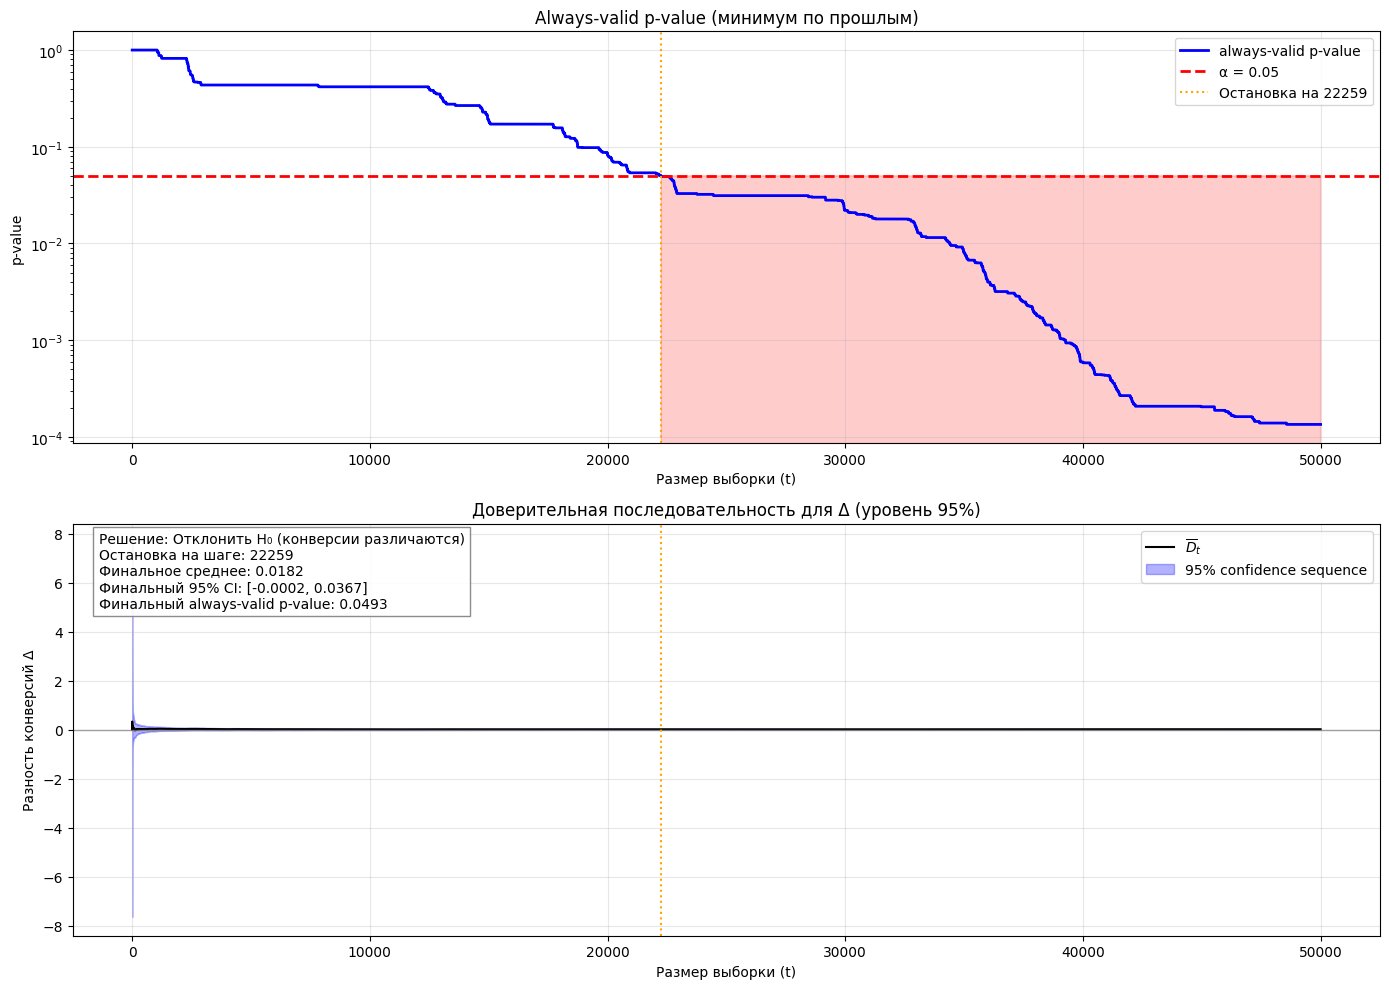

In [29]:
# Параметры эксперимента
CONVERSION_A = 0.10
CONVERSION_B = 0.12   # истинная разница 2%
SAMPLE_SIZE = 50_000
RANDOM_SEED = 666

# Генерация данных
data_A, data_B = generate_ab_data(
    conversion_A=CONVERSION_A,
    conversion_B=CONVERSION_B,
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED
)

# Параметры AVI
alpha = 0.05

# Запуск теста
result = run_avi_test(
    data_A=data_A,
    data_B=data_B,
    alpha=alpha,
    max_samples=None,
    stop_on_pvalue=True
)

# Визуализация
plot_avi_results(result)
plt.show()

### Group Sequential Testing

Group Sequential Tests являются адаптацией обычной z-статистики под условия подглядываний. В этом методе в качестве функции используется обычная z-статистика, посчитанная на группе, а границы строятся на основе выбранной alpha-spending функции. Alpha-spending функция задает правило, по которому уровень значимости $\alpha$ расходуется на каждом этапе анализа, чтобы общий уровень значимости эксперимента не превышал значение  $\alpha$.



Пусть у нас есть броуновское движение $W(t) : 0 < t ≤ 1$ и мы хотим посмотреть, в какое время  $\tau$ процесс пересечет границу  $b(t) = z_{\alpha/2}$ в первый раз. Если  $\alpha^*(t) = \mathbb{P}(\tau \leq t \mid 0 \leq t \leq 1)$,то известно:
$$
\alpha^*(t) = \begin{cases}     0, & \text{если } t = 0, \\     2 - 2 \cdot \Phi\left(\frac{z_{\alpha/2}}{\sqrt{t}}\right), & \text{если } t > 0, \end{cases}
$$
где  $\Phi$— функция стандартного нормального распределения. Заметим, что $\alpha^*(t)$ — возрастающая функция, такая, что $\alpha^*(1) = \alpha$.Допустим, мы подсматриваем, пересекло ли броуновское движение границу, только в моменты  $\leq t_1, t_2, \dots, t_K = 1$.Можем назначить кумулятивную вероятность пересечения границы  $\alpha^*(t_1)$ точке  $t_1$ ,определив $b_1$ так, чтобы она удовлетворяла следующему:

$$
\mathbb{P}(B(t_1) > b_1) = \mathbb{P}(\tau \in [0, t_1]) = \alpha^*(t_1)
$$
Точно так же мы можем определить константы  $b_i = b_2, b_3, \dots, b_K$ так, чтобы:

$$
\mathbb{P}(B(t_j) < b_j, j = 1, \dots, i-1; B(t_i) > b_i) =  \mathbb{P}(\tau \in [t_{i-1}, t_i]) = \alpha^*(t_{i}) - \alpha^*(t_{i-1}).
$$

$b_1$ находится аналитически, а вот $b_2, \dots, b_K$ требуют численных методов интегрирования. Заметим, что $b_i$ зависит только от выбора $\alpha^*(t)$ и предыдущих $b_j, 1 \leq j  < i$.

В примере выше $\alpha^*(t)$ — alpha-spending-функция.

Идея GST заключается в том, что можно брать другие функции распределения α, которые строго возрастают по t и удовлетворяют условию $\alpha^*(1) = \alpha$. На основе последовательной траты $\alpha$ (то есть, на основе распределения уровня значимости на каждом промежуточном этапе анализа) и вычисляются границы, чтобы вероятность ошибки первого рода контролировалась.

**Выбор alpha-spending function**

Базово есть 5 семейств таких функций:

$\alpha - \text{номинальное значение ошибки 1 рода} \left( \text{если гипотеза двусторонняя, то значение берётся вдвое меньше} \right)$

$\mathrm{t} - \text{доля пользователей, которое уже попала в тест в момент оценки эксперимента} \left( \mathrm{t} \in \left[0;1 \right] \right)$

| Наименование | Функция $\alpha(t)$ |
|---|---|
| O'Brien-Fleming | $\alpha(t) = 2 - 2 \cdot \Phi\left( \frac{Z_0}{\sqrt{t}} \right)$ |
| Pocock | $\alpha(t) = \alpha \cdot \ln \left(1 + (\mathrm{e} - 1) \cdot t \right)$ |
| Uniform | $\alpha(t) = \alpha \cdot t$ |
| Kim & DeMets Power Family | $\alpha(t) = \alpha \cdot t^{x}$ |
| Hwang, Shih & De Cani Gamma family | $\alpha(t) = \begin{cases} \alpha \cdot t, & \text{если } \gamma = 0 \\ \alpha \cdot \frac{1 - e^{-\gamma \cdot t}}{1 - e^{-\gamma}}, & \text{если } \gamma \neq 0 \end{cases}$ |

#### Функции

In [30]:
@dataclass
class AlphaSpendingConfig:
    alpha: float = 0.05
    beta: float = 0.2
    mu: float = 1.0
    sigma: float = 10.0
    n_peek_start: int = 100
    n_peek_step: int = 50


def select_naive_alpha(n: int, N: int, N_peek: List[int], alpha: float) -> float:
    """Фиксированный уровень значимости без поправок."""
    return float(alpha)


def select_alpha_bonferroni(n: int, N: int, N_peek: List[int], alpha: float) -> float:
    """Поправка Бонферрони по количеству взглядов."""
    P = len(N_peek)
    return float(alpha / P)


def select_uniform_alpha(n: int, N: int, N_peek: List[int], alpha: float) -> float:
    """Линейное распределение альфы по ходу эксперимента."""
    t = n / N
    return float(alpha * t)


def select_alpha_gst_pocock(n: int, N: int, N_peek: List[int], alpha: float) -> float:
    """Alpha-spending функция Pocock."""
    t = n / N
    return float(alpha * np.log(1 + (np.exp(1) - 1) * t))


def select_alpha_gst_obrien_fleming(n: int, N: int, N_peek: List[int], alpha: float, rho: float = 1.0) -> float:
    """Alpha-spending функция O'Brien-Fleming."""
    t = n / N
    return float(4 - 4 * norm.cdf(norm.ppf(1 - alpha / 4) / t ** (rho / 2)))


def select_power_family_alpha(n: int, N: int, N_peek: List[int], alpha: float, x: float = 3.0) -> float:
    """Power-family правило: расходуем ошибку пропорционально t^x."""
    t = n / N
    return float(alpha * t**x)


def select_gamma_family_alpha(n: int, N: int, N_peek: List[int], alpha: float, g: float = 5.0) -> float:
    """Gamma-family правило из Jennison & Turnbull."""
    t = n / N
    if g == 0:
        return float(alpha * t)
    return float(alpha * (1 - math.exp(-g * t)) / (1 - math.exp(-g)))


def plot_peeking(dfi: pd.DataFrame, obs: np.ndarray, N_peek: List[int], k: int = 1) -> None:
    """Показывает доверительные интервалы в моменты промежуточных взглядов."""
    ns = np.reshape(np.arange(1, np.shape(obs)[0] + 1), (-1, 1))
    means = np.cumsum(obs, axis=0) / ns
    fig, ax = plt.subplots(figsize=(17, 4))
    for n in N_peek:
        color = "red" if dfi[f"width{n}"][k] > dfi[f"mean{n}"][k] else "green"
        ax.errorbar(x=[n - 1], y=dfi[f"mean{n}"][k], yerr=dfi[f"width{n}"][k], c=color, lw=0, elinewidth=2, capsize=6, marker="o", markersize=6)
    sns.lineplot(x=range(30, np.shape(obs)[0]), y=means[:, k][30:], lw=3, ax=ax)
    ax.axhline(y=0, lw=1)
    ax.set(xlim=(0, np.shape(obs)[0] + 10), xlabel="Номер наблюдения", title="Среднее и интервалы на промежуточных шагах")


def compute_intervals(select_alpha, obs: np.ndarray, N_peek: List[int], mu: float, alpha: float = 0.05, **kwargs) -> pd.DataFrame:
    """Считает доверительные интервалы и показатели покрытия для набора взглядов."""
    N, K = np.shape(obs)
    ns = np.reshape(np.arange(1, N + 1), (-1, 1))
    means = np.cumsum(obs, axis=0) / ns
    stdevs = np.sqrt(np.cumsum((obs - means) ** 2, axis=0) / ns)

    df_intervals = pd.DataFrame({"k": range(K)})
    df_intervals["rejected_0"] = False
    df_intervals["rejected_1"] = False
    df_intervals["length"] = max(N_peek)
    for n in N_peek:
        df_intervals[f"mean{n}"] = means[n - 1, :]
        width = stats.norm.ppf(1 - select_alpha(n, N, N_peek, alpha, **kwargs) / 2) * stdevs[n - 1, :] / np.sqrt(n)
        df_intervals[f"width{n}"] = width
        df_intervals[f"lowerb{n}"] = means[n - 1, :] - width
        df_intervals[f"upperb{n}"] = means[n - 1, :] + width
        df_intervals[f"coverage{n}"] = (df_intervals[f"lowerb{n}"] <= mu) & (df_intervals[f"upperb{n}"] >= mu)
        df_intervals["rejected_0"] = df_intervals["rejected_0"] | (df_intervals[f"lowerb{n}"] >= 0) | (df_intervals[f"upperb{n}"] <= 0)
        df_intervals[f"power{n}"] = df_intervals["rejected_0"]
        df_intervals["rejected_1"] = df_intervals["rejected_1"] | ~df_intervals[f"coverage{n}"]
        df_intervals[f"falsep{n}"] = df_intervals["rejected_1"]
        df_intervals["length"] = np.minimum(df_intervals["length"], n) * df_intervals["rejected_0"] + max(N_peek) * (1 - df_intervals["rejected_0"])
    return df_intervals


def check_performance(dfi: pd.DataFrame) -> pd.DataFrame:
    """Агрегирует покрытие, мощность и FPR по всем симуляциям."""
    df_perf = dfi[list(dfi.filter(regex="coverage|power|falsep"))].copy()
    df_perf["idx"] = 1
    df_perf = df_perf.groupby("idx", as_index=False).mean()
    df_perf = pd.wide_to_long(df_perf, stubnames=["coverage", "power", "falsep"], i="idx", j="n").reset_index().drop(columns="idx")
    return df_perf


def plot_coverage_power(dfi: pd.DataFrame, alpha: float = 0.05, beta: float = 0.8) -> None:
    """Рисует покрытие, мощность и FPR при разных моментах взгляда."""
    df_perf = check_performance(dfi)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 3))

    sns.lineplot(df_perf, x="n", y="coverage", c="C0", ax=ax1)
    ax1.axhline(y=1 - alpha, ls="--", lw=2, c="C0")
    ax1.set(title="Покрытие", ylabel="", ylim=(0.90, 1.01))

    sns.lineplot(df_perf, x="n", y="power", c="C1", ax=ax2)
    ax2.axhline(y=beta, ls="--", lw=2, c="C1")
    ax2.set(title="Мощность", ylabel="", ylim=(0.60, 1.05))

    sns.lineplot(df_perf, x="n", y="falsep", c="C2", ax=ax3)
    ax3.axhline(y=alpha, ls="--", lw=2, c="C2")
    ax3.set(title="False Positive Rate", ylabel="FPR", ylim=(-0.01, 0.5))


#### Реализация

Расчетный размер выборки T: 3139
Средняя длина GST: 1018
Экономия наблюдений: 2121 (68%)


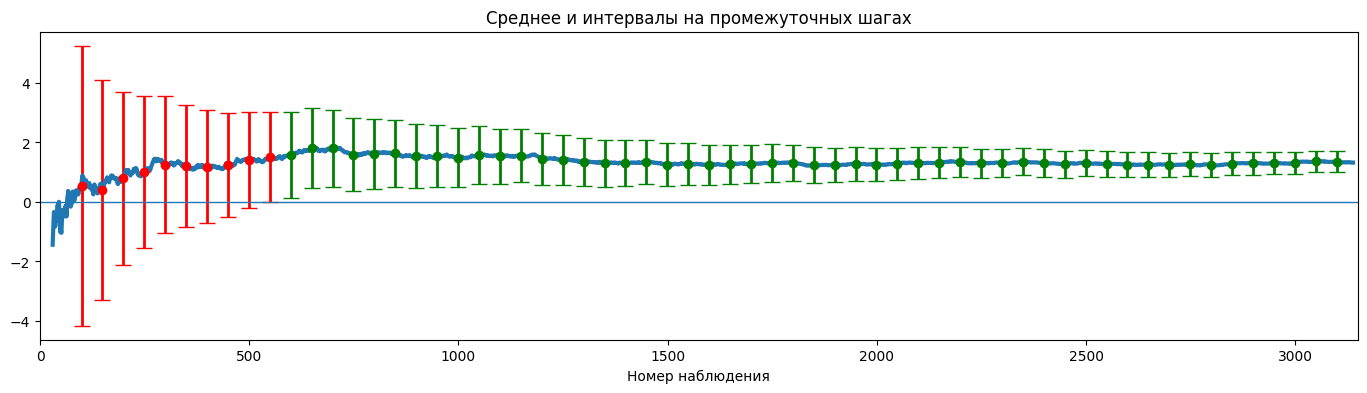

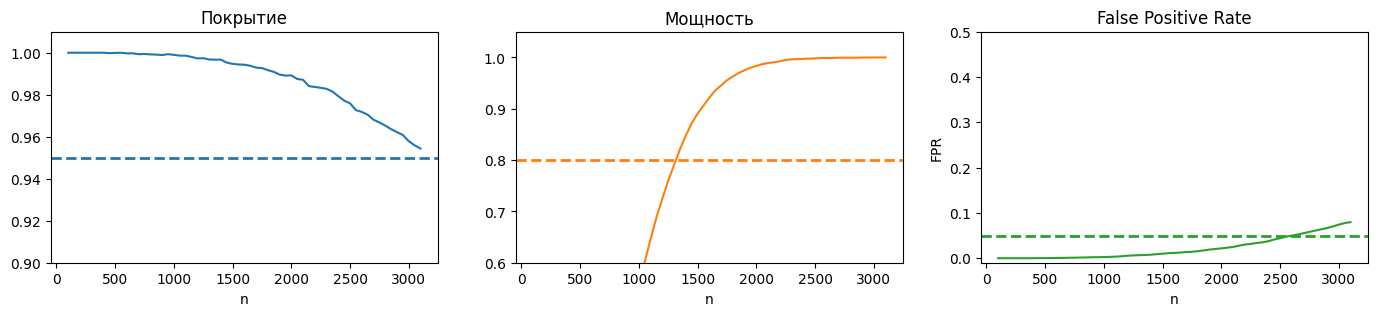

In [31]:
spending_config = AlphaSpendingConfig()

ppf = sp.stats.norm(0, 1).ppf
z_alpha = ppf(1 - spending_config.alpha / 2)
z_beta = ppf(1 - spending_config.beta)
N = int((2 * spending_config.sigma * (z_alpha + z_beta) / spending_config.mu) ** 2)

K = 10_000
obs = np.random.normal(spending_config.mu, spending_config.sigma, size=(N, K))

N_peek = np.arange(spending_config.n_peek_start, N + 1, spending_config.n_peek_step, dtype=int)

dfi_naive = compute_intervals(select_power_family_alpha, obs, N_peek.tolist(), mu=spending_config.mu, x=3)
plot_peeking(dfi_naive, obs, N_peek.tolist(), k=69)
plot_coverage_power(dfi_naive, alpha=spending_config.alpha, beta=1 - spending_config.beta)

sample_win_pct = np.round((N - dfi_naive.length.mean()) * 100 / N, 2)
print(
    f"Расчетный размер выборки T: {N:.0f}\n"
    f"Средняя длина GST: {dfi_naive.length.mean():.0f}\n"
    f"Экономия наблюдений: {(N - dfi_naive.length.mean()):.0f} ({sample_win_pct:.0f}%)"
)

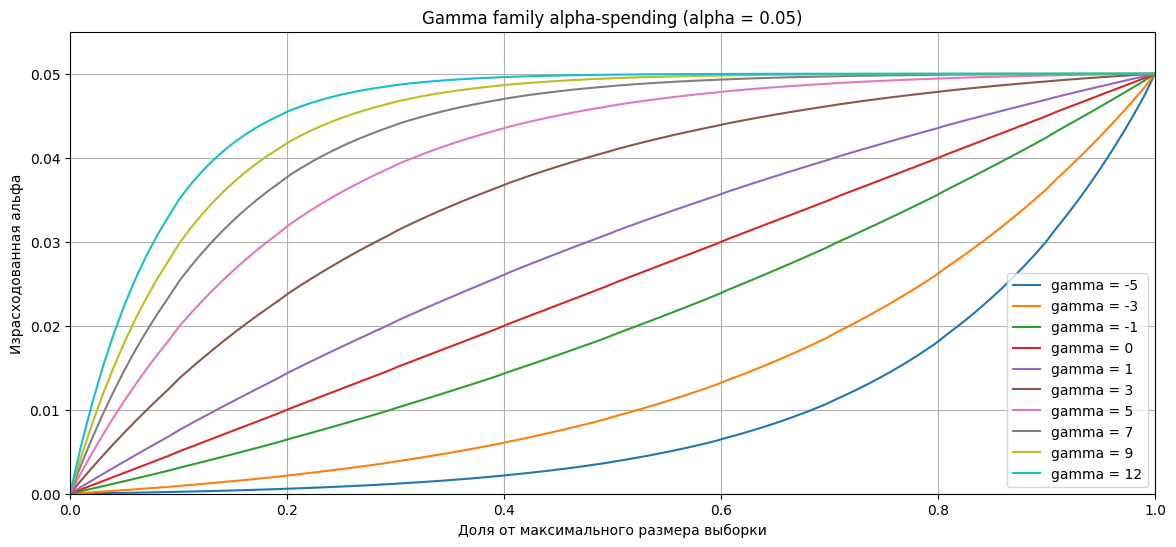

In [ ]:
# Gamma-family пример
alpha = 0.05
gamma_values = [-5, -3, -1, 0, 1, 3, 5, 7, 9, 12]
N_gamma = 1_000
t_values = np.linspace(0, 1, 100)

plt.figure(figsize=(14, 6))
for g in gamma_values:
    alpha_values = [select_gamma_family_alpha(int(t * N_gamma), N_gamma, None, alpha, g) for t in t_values]
    plt.plot(t_values, alpha_values, label=f"gamma = {g}")

plt.xlabel("Доля от максимального размера выборки")
plt.ylabel("Израсходованная альфа")
plt.title(f"Gamma family alpha-spending (alpha = {alpha})")
plt.grid(True)
plt.xlim(0, 1)
plt.ylim(0, alpha * 1.1)
plt.legend()
plt.show()

### Сравнение подходов

**Always Valid Inference**

* Плюсы
  1. Простота реализации.
  2. Допускает неограниченную выборку, и ожидаемый размер выборки не требуется заранее.
  3. Допускает произвольные правила остановки.
  4. Поддержка потоковых и пакетных данных.

* Минусы
  1. Требует от экспериментатора выбора параметров смешанного распределения, т.е. распределения, описывающего эффект при альтернативной гипотезе.
  2. Сложнее понять тем, кто прошел обучение по традиционной проверке гипотез. Вероятно, потребуется некоторое время, прежде чем вводные курсы по статистике будут рассматривать эти тесты.
  3. По своей сути обладает меньшей производительностью при пакетном анализе данных по сравнению с потоковой обработкой.

**Group Sequential Testing**

* Плюсы

  1. Не нужно заранее решать, сколько тестов проведить или на каком этапе сбора данных их проведить. Если вообще не просматривать данные во время сбора, тест после завершения фазы сбора данных будет в точности соответствовать традиционному z-тесту.
  2. Альфа может быть потрачена произвольно в течение времени, и альфа тратится только во время просмотра — если пропустить просмотр, то можно сохранить неиспользованную альфу на потом.
  3. Легко объяснить благодаря связи с z-тестами.

* Минусы

  1. Необходимо заранее знать или иметь возможность оценить максимальный размер выборки.
  2. Необходимо выбрать альфа-функцию расходов. Если всегда достигается запланированный размера выборки, этот выбор некритичен, но если наблюдается слишком мало пользователей, выбор функции расходов может существенно повлиять на свойства мощности.
  3. Критические значения, используемые в тесте, необходимо получить путем численного решения интегралов. Эта численная задача становится более сложной при большом количестве прерывистых анализов, и поэтому нецелесообразно использовать GST в потоковом режиме.
